In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("northwind.db")

In [4]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


#Northwind Database Analysis

## Query 1: Top 10 Selling Products

In [5]:
query1 = """
SELECT
    Products.ProductName,
    SUM("Order Details".Quantity) AS TotalSold
FROM "Order Details"
JOIN Products
ON Products.ProductID = "Order Details".ProductID
GROUP BY Products.ProductName
ORDER BY TotalSold DESC
LIMIT 10;
"""

top_products = pd.read_sql(query1, conn)

top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


In [7]:
import matplotlib.pyplot as plt

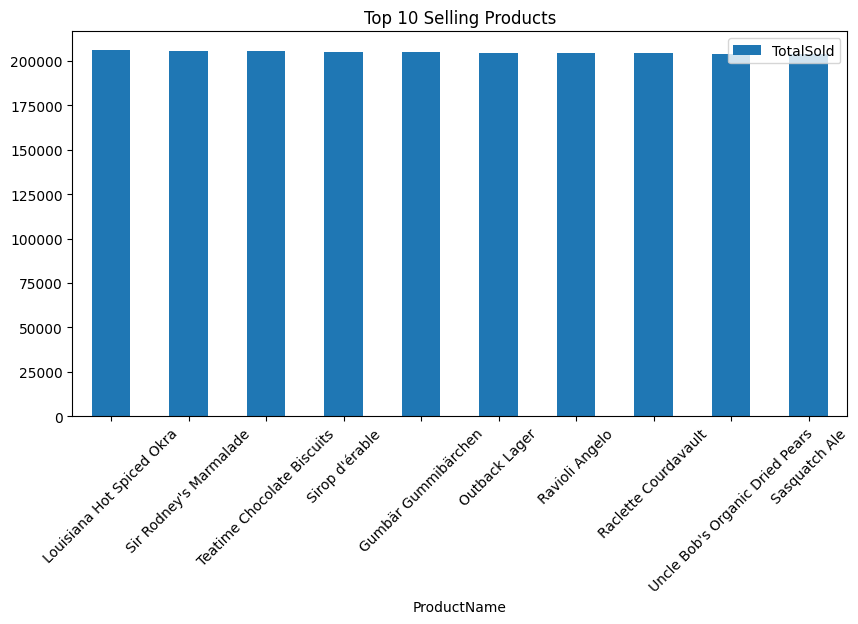

In [8]:
top_products.plot(
    x="ProductName",
    y="TotalSold",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Selling Products")
plt.xticks(rotation=45)
plt.show()

## Query 2: Top 10 Customers by Revenue



In [10]:
query2 = """
SELECT
    Customers.CompanyName,
    ROUND(SUM("Order Details".UnitPrice *
              "Order Details".Quantity *
              (1 - "Order Details".Discount)), 2) AS Revenue
FROM Customers
JOIN Orders
ON Customers.CustomerID = Orders.CustomerID
JOIN "Order Details"
ON Orders.OrderID = "Order Details".OrderID
GROUP BY Customers.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query2, conn)
top_customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


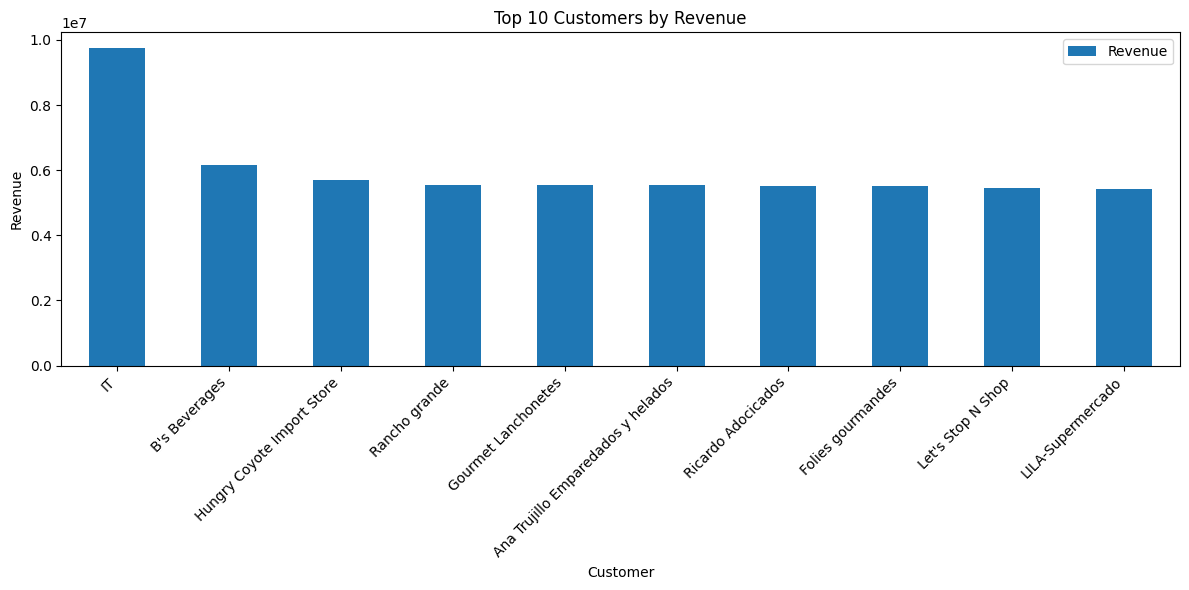

In [11]:
top_customers.plot(
    x="CompanyName",
    y="Revenue",
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## Query 3: Monthly Sales Trends



In [12]:
query3 = """
SELECT
    strftime('%Y-%m', Orders.OrderDate) AS Month,
    ROUND(SUM("Order Details".UnitPrice *
              "Order Details".Quantity *
              (1 - "Order Details".Discount)), 2) AS Sales
FROM Orders
JOIN "Order Details"
ON Orders.OrderID = "Order Details".OrderID
GROUP BY Month
ORDER BY Month;
"""

monthly_sales = pd.read_sql(query3, conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


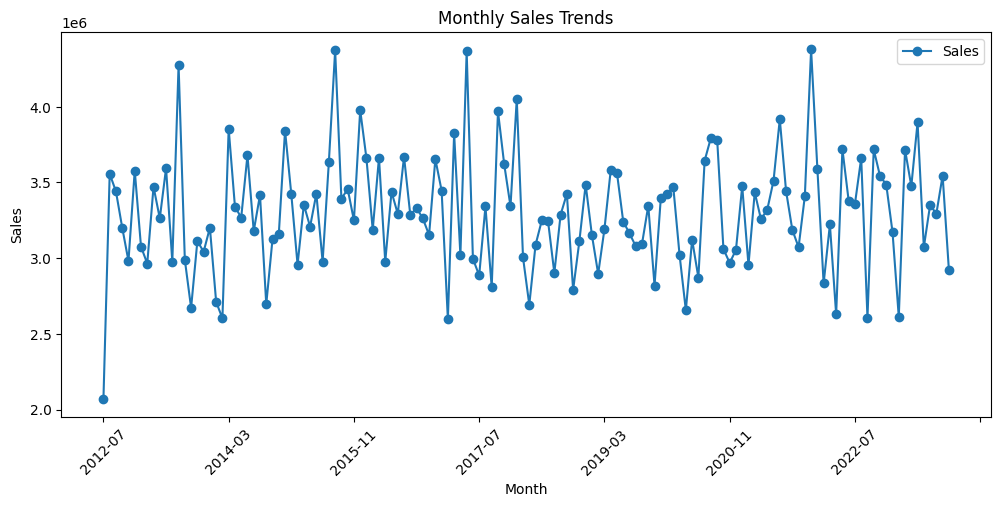

In [13]:
monthly_sales.plot(
    x="Month",
    y="Sales",
    kind="line",
    marker="o",
    figsize=(12,5)
)

plt.title("Monthly Sales Trends")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()



## Query 4: Best Performing Product Categories


In [14]:
query4 = """
SELECT
    Categories.CategoryName,
    ROUND(SUM("Order Details".UnitPrice *
              "Order Details".Quantity *
              (1 - "Order Details".Discount)), 2) AS Revenue
FROM Categories
JOIN Products
ON Categories.CategoryID = Products.CategoryID
JOIN "Order Details"
ON Products.ProductID = "Order Details".ProductID
GROUP BY Categories.CategoryName
ORDER BY Revenue DESC;
"""

category_sales = pd.read_sql(query4, conn)
category_sales

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


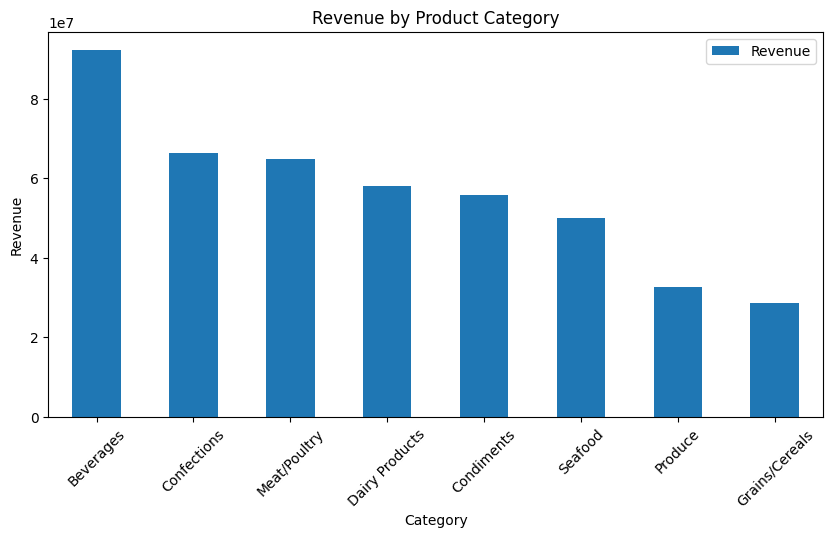

In [15]:
category_sales.plot(
    x="CategoryName",
    y="Revenue",
    kind="bar",
    figsize=(10,5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()



## Query 5: Customer Purchase Frequency

In [16]:
query5 = """
SELECT
    Customers.CompanyName,
    COUNT(Orders.OrderID) AS NumberOfOrders
FROM Customers
JOIN Orders
ON Customers.CustomerID = Orders.CustomerID
GROUP BY Customers.CompanyName
ORDER BY NumberOfOrders DESC;
"""

purchase_frequency = pd.read_sql(query5, conn)
purchase_frequency

,CompanyName,NumberOfOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
...,...,...
87,Around the Horn,156
88,La corne d'abondance,155
89,Furia Bacalhau e Frutos do Mar,155
90,FISSA Fabrica Inter. Salchichas S.A.,155


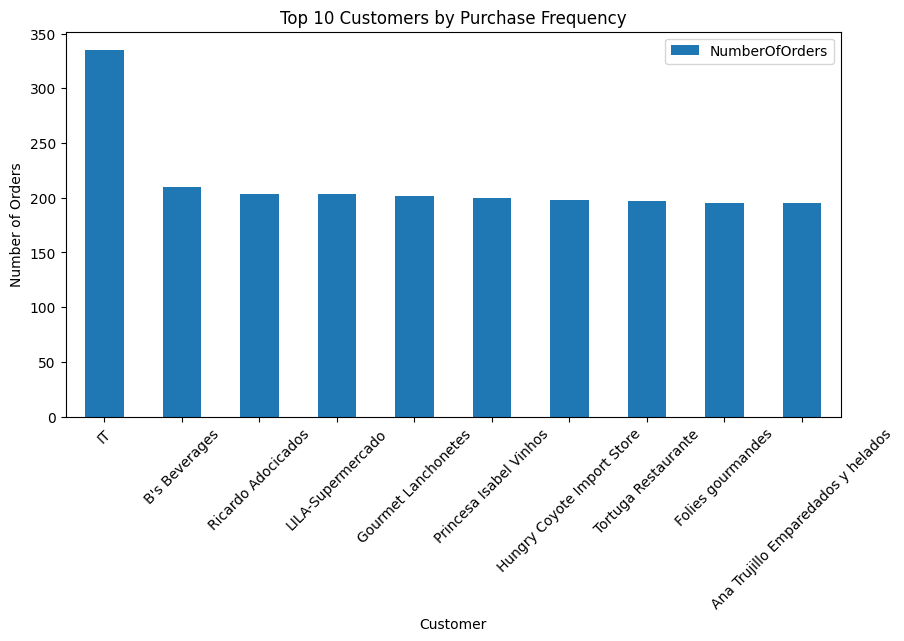

In [17]:
purchase_frequency.head(10).plot(
    x="CompanyName",
    y="NumberOfOrders",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers by Purchase Frequency")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [18]:
top_products.describe()

,TotalSold
count,10.000000
mean,204753.100000
std,820.692452
min,203667.000000
25%,204165.500000
50%,204582.000000
75%,205366.500000
max,206213.000000


In [20]:
top_customers.describe()



,Revenue
count,1.000000e+01
mean,6.017294e+06
std,1.326135e+06
min,5.437438e+06
25%,5.510256e+06
50%,5.543333e+06
75%,5.663295e+06
max,9.745371e+06


In [21]:
monthly_sales.describe()



,Sales
count,1.360000e+02
mean,3.296961e+06
std,3.885097e+05
min,2.066219e+06
25%,3.050957e+06
50%,3.285466e+06
75%,3.518739e+06
max,4.377795e+06


In [22]:
category_sales.describe()



,Revenue
count,8.000000e+00
mean,5.604833e+07
std,2.010646e+07
min,2.856853e+07
25%,4.561648e+07
50%,5.690662e+07
75%,6.524531e+07
max,9.216318e+07


In [23]:


purchase_frequency.describe()

,NumberOfOrders
count,92.000000
mean,176.978261
std,20.942086
min,154.000000
25%,165.750000
50%,175.000000
75%,184.250000
max,335.000000


# Business Insights

1. **Louisiana Hot Spiced Okra** is the top-selling product, with **206,213 units sold**, making it the most popular product in the dataset.

2. **IT** is the highest revenue-generating customer, contributing **9,745,371.29** in total revenue. This customer has the greatest impact on overall sales.

3. Monthly sales show noticeable fluctuations over time. The highest monthly sales occurred during the peak sales period (based on the monthly sales analysis), indicating seasonal or demand-driven variations.

4. The **Beverages** category generated the highest revenue (**92,163,184.18**), making it the best-performing product category.

5. **IT** placed the highest number of orders (**335 orders**), indicating a strong and loyal customer relationship with frequent purchases.